In [1]:
%matplotlib notebook

# Plotting fitted PES functions

- Fittings done with HPO2_v4 have a bug (edit: actually a feature) where the functional form of angle $A_{poh}$ is inverted. Eg. $\beta_{eq} - \beta $ instead of $\beta - \beta_{eq} $ 
(15:44 05/12/2025 EDIT): the v4.f90 file actually fits $\rho = \pi - \beta$ to the argument $\rho - \rho_{eq} $ which then leads to $\beta$ being $\beta_{eq} -\beta$. We should switch $\beta $ to the coordinate $\rho$

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import make_pes as mpes
from scipy.optimize import minimize

In [18]:
p_test, o_test = mpes.get_coeffs_orders('6D_6.res')
nonlin_p_test = mpes.get_non_linear_p('6D_6.res')
pes = mpes.get_pes_v4(p_test, nonlin_p_test.copy(), o_test)

print(nonlin_p_test)

[  1.46461729   1.61099546   0.96380778 110.46377558 115.67092131
   2.049        1.92         2.097     ]


<IPython.core.display.Javascript object>


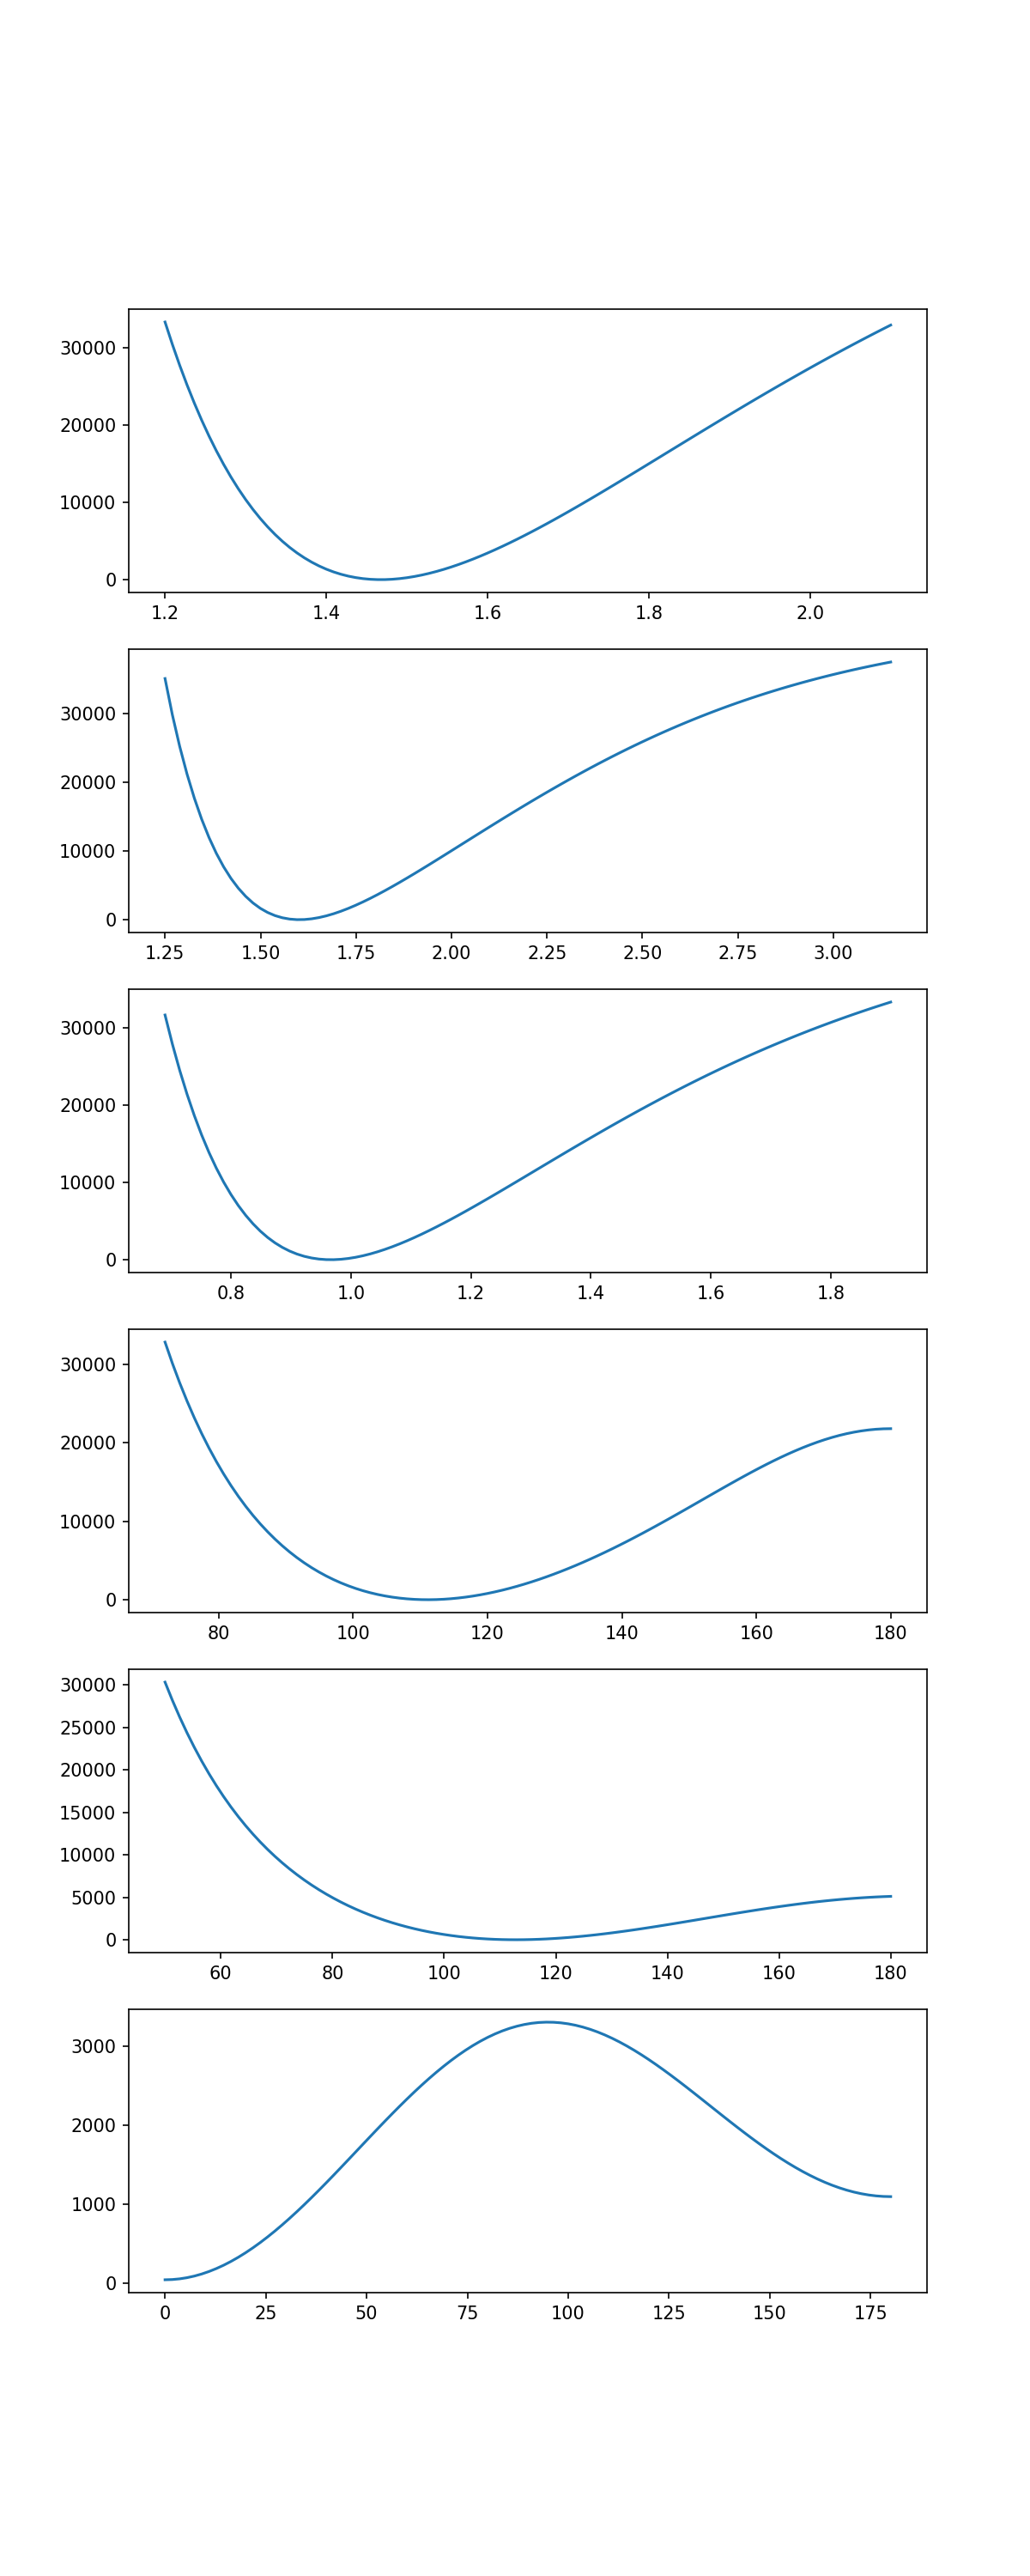

In [17]:
#equilibriums = [1.46833127, 1.60429226, 0.96798292, 110.72852741, 113.05478765, 0]
equilibriums = [1.61099378, 1.46461659, 0.96380201, 110.46251809, 115.68113572, 0]

coordinate_lower_bounds = [1.20, 1.25, 0.69, 72, 50, 0]
coordinate_upper_bounds = [2.10, 3.15, 1.9, 180, 180, 180]

geometry1d = np.zeros((100, 6))
for j in range(5):
    geometry1d[:, j] = nonlin_p_test[j]

fig, ax = plt.subplots(6,1, figsize=(8,20))

for i in range(6):
    geometry_1d = geometry1d.copy()
    geometry_1d[:, i] = np.linspace(coordinate_lower_bounds[i],
                                    coordinate_upper_bounds[i],
                                    100)
    ax[i].plot(geometry_1d[:, i], pes(geometry_1d))


<IPython.core.display.Javascript object>


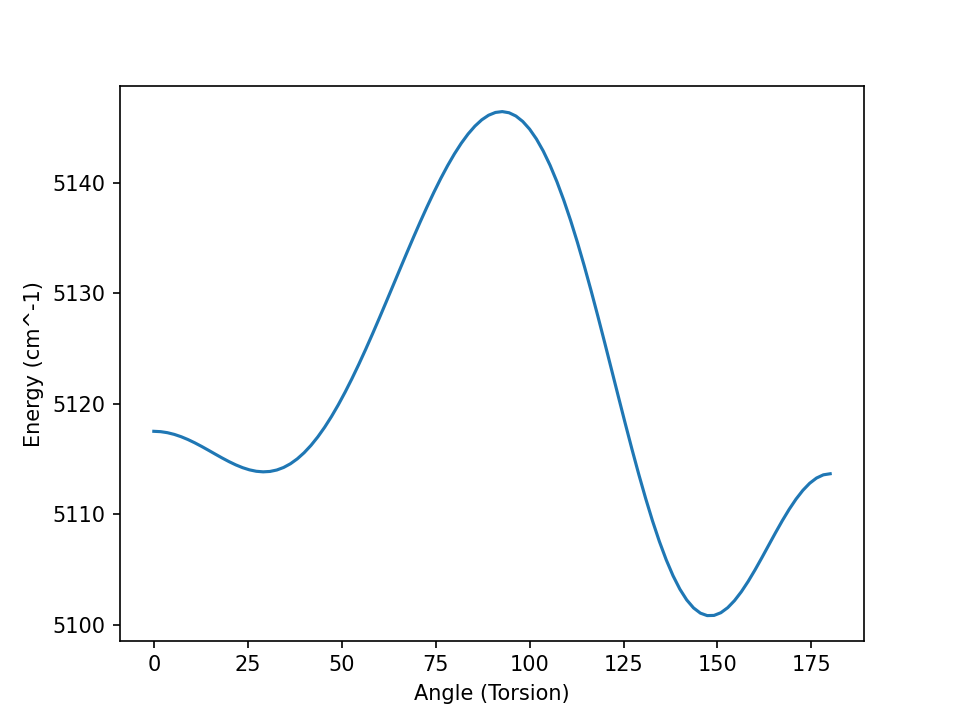

Text(0.5, 0, 'Angle (Torsion)')

In [5]:
geometry_linear = np.zeros((100, 6))
for j in range(5):
    geometry_linear[:, j] = nonlin_p_test[j]
geometry_linear[:, 4] = 180.00
geometry_linear[:, 5] = np.linspace(0,180, 100)

plt.figure()
plt.plot(np.linspace(0,180, 100), pes(geometry_linear))
plt.ylabel('Energy (cm^-1)')
plt.xlabel('Angle (Torsion)')

<IPython.core.display.Javascript object>


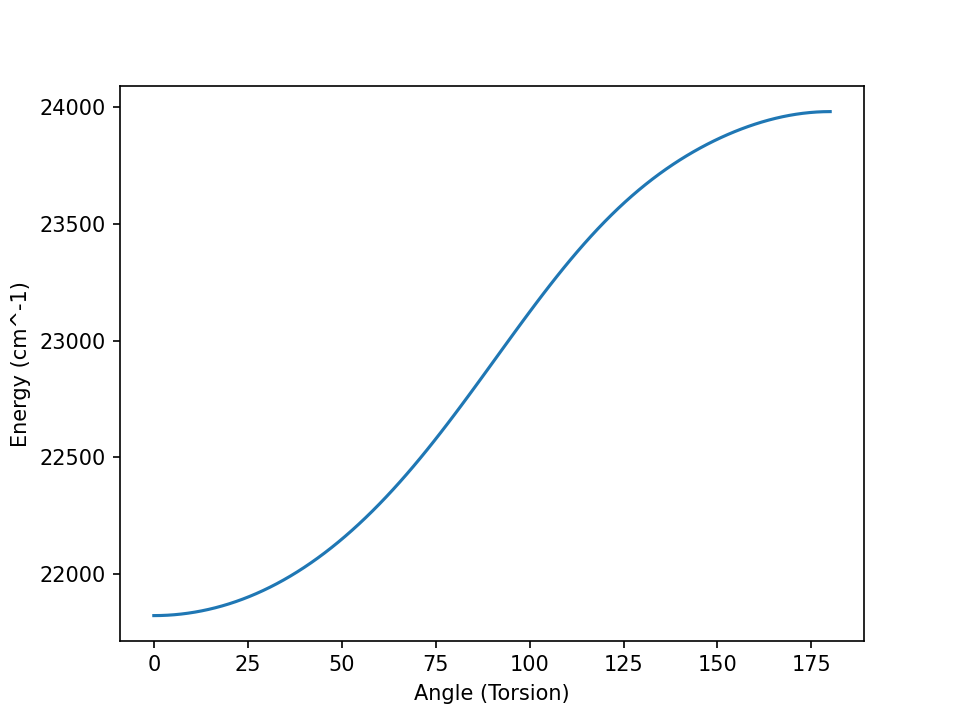

Text(0.5, 0, 'Angle (Torsion)')

In [6]:
geometry_linear = np.zeros((100, 6))
for j in range(5):
    geometry_linear[:, j] = nonlin_p_test[j]
geometry_linear[:, 3] = 180.00
geometry_linear[:, 5] = np.linspace(0,180, 100)

plt.figure()
plt.plot(np.linspace(0,180, 100), pes(geometry_linear))
plt.ylabel('Energy (cm^-1)')
plt.xlabel('Angle (Torsion)')

<IPython.core.display.Javascript object>


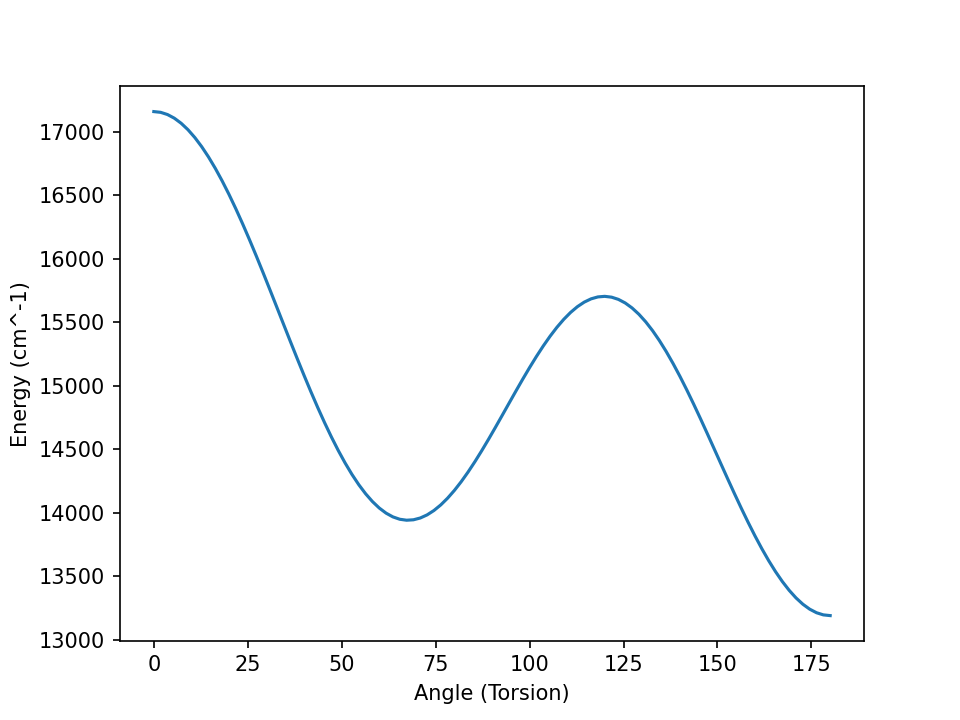

Text(0.5, 0, 'Angle (Torsion)')

In [7]:
geometry_linear = np.zeros((100, 6))
for j in range(5):
    geometry_linear[:, j] = nonlin_p_test[j]
geometry_linear[:, 3] = 180.00
geometry_linear[:, 4] = 180.00
geometry_linear[:, 5] = np.linspace(0,180, 100)

plt.figure()
plt.plot(np.linspace(0,180, 100), pes(geometry_linear))
plt.ylabel('Energy (cm^-1)')
plt.xlabel('Angle (Torsion)')

In [1]:
equilibriums = [1.46833127, 1.60429226, 0.96798292, 110.72852741, 113.05478765, 0]
coordinate_lower_bounds = [1.22, 1.3, 0.77, 77, 57, 0]
coordinate_upper_bounds = [2.0, 2.4, 1.5, 180, 180, 180]

rpo2_grid = np.linspace(1.3, 2.4, 20)
rpo1_grid = np.linspace(1.22, 2.0, 20)
r1_r2_mesh = np.meshgrid(rpo1_grid, rpo2_grid)
rpo1_mesh = r1_r2_mesh[0]
rpo2_mesh = r1_r2_mesh[1]

geometry_r1_r2 = np.zeros((len(rpo1_grid)*len(rpo2_grid), 
                           6) )
geometry_r1_r2[:, 0] = rpo1_mesh.flatten()
geometry_r1_r2[:, 1] = rpo2_mesh.flatten()

for j in range(2,6):
    geometry_r1_r2[:, j] = equilibriums[j]

pes_vals = pes(geometry_r1_r2)
pes_vals = np.reshape(pes_vals, 
                        (len(rpo1_grid), len(rpo2_grid)) #shape 
                       )


NameError: name 'np' is not defined

<IPython.core.display.Javascript object>


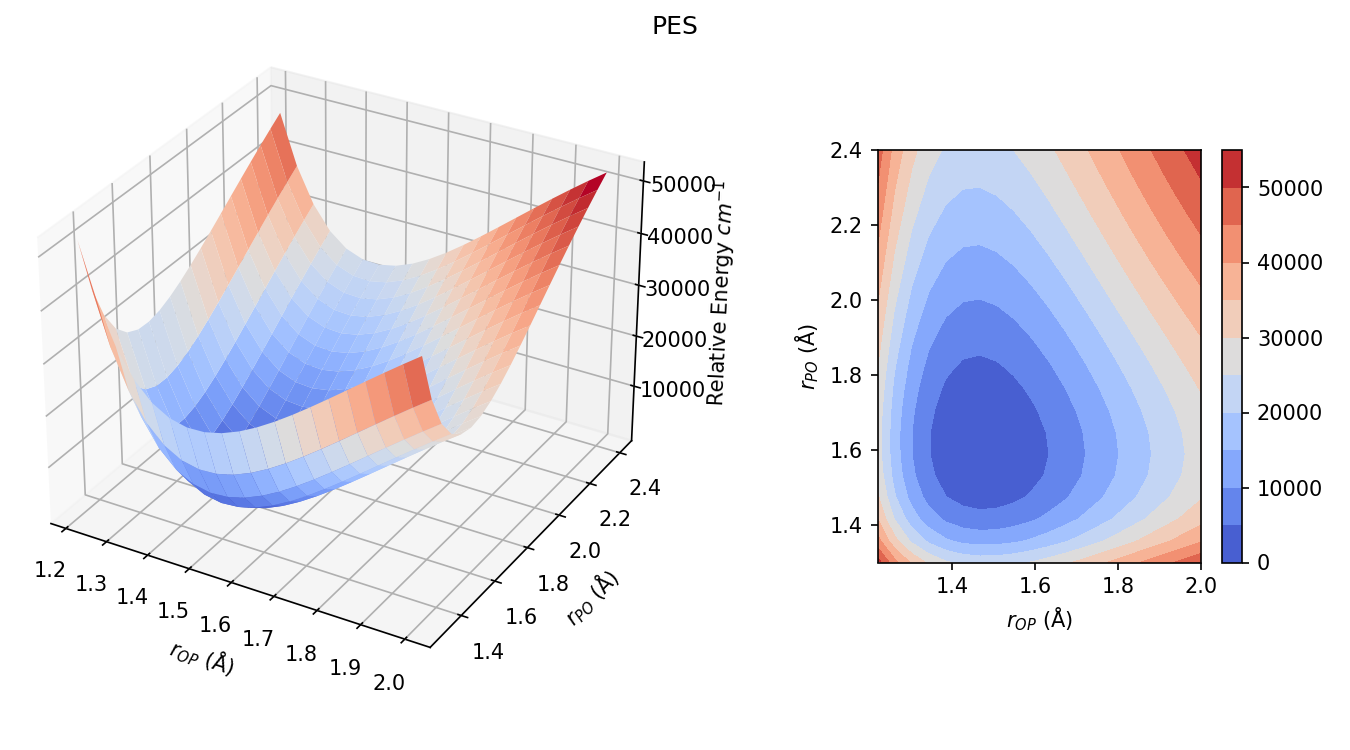

In [9]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('PES')
ax_3d = fig.add_axes([-0.1, 0.08, 0.7, 0.9], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    rpo1_mesh, rpo2_mesh, pes_vals,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
#ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_3d.set_ylabel(r'$r_{PO}$ (Å)') #rpo2
ax_3d.set_zlabel(r'Relative Energy $cm^{-1}$');
ax_3d.axis('tight');

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.3, 0.55])  
contour = ax_contour.contourf(
    rpo1_mesh, rpo2_mesh, pes_vals,
    levels=10, #num contour lines
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_contour.set_ylabel(r'$r_{PO}$ (Å)') #rpo2

plt.colorbar(contour, ax=ax_contour)
plt.show()

In [10]:
tau_grid = np.linspace(-80, 260, 50)
rpo1_grid = np.linspace(1.34, 1.64, 20)
rpo1_tau_mesh = np.meshgrid(rpo1_grid, tau_grid)
rpo1_mesh = rpo1_tau_mesh[0]
tau_mesh = rpo1_tau_mesh[1]

geometry_rpo1_tau = np.zeros((len(rpo1_grid)*len(tau_grid), 
                           6) )
geometry_rpo1_tau[:, 0] = rpo1_mesh.flatten()
geometry_rpo1_tau[:, 5] = tau_mesh.flatten()

for j in range(1,5):
    geometry_rpo1_tau[:, j] = equilibriums[j]
    
pes_vals = pes(geometry_rpo1_tau)
pes_vals = np.reshape(pes_vals, 
                        (len(tau_grid), len(rpo1_grid)) #shape 
                       )

<IPython.core.display.Javascript object>


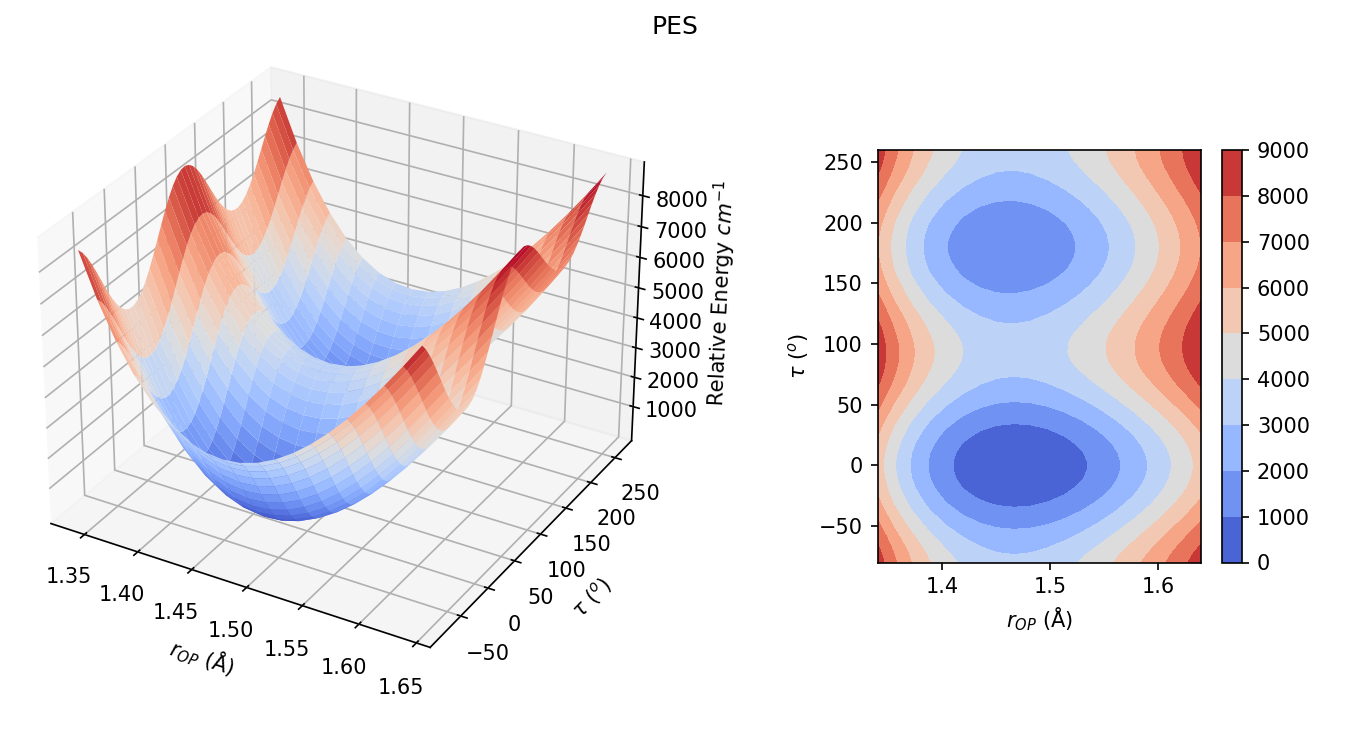

In [11]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('PES')
ax_3d = fig.add_axes([-0.1, 0.08, 0.7, 0.9], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    rpo1_mesh, tau_mesh, pes_vals,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
#ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_3d.set_ylabel(r'$\tau$ ($^{o}$)') #rpo2
ax_3d.set_zlabel(r'Relative Energy $cm^{-1}$');
ax_3d.axis('tight');

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.3, 0.55])  
contour = ax_contour.contourf(
    rpo1_mesh, tau_mesh, pes_vals,
    levels=10,
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$r_{OP}$ (Å)') #rpo1
ax_contour.set_ylabel(r'$\tau$ ($^{o}$)') #rpo2

plt.colorbar(contour, ax=ax_contour)
plt.show()

In [12]:
tau_grid = np.linspace(-80, 260, 40)
apoh_grid = np.linspace(75, 180, 20)
apoh_tau_mesh = np.meshgrid(apoh_grid, tau_grid)
apoh_mesh = apoh_tau_mesh[0]
tau_mesh = apoh_tau_mesh[1]

geometry_apoh_tau = np.zeros((len(apoh_grid)*len(tau_grid), 
                           6) )
geometry_apoh_tau[:, 4] = apoh_mesh.flatten()
geometry_apoh_tau[:, 5] = tau_mesh.flatten()

for j in range(4):
    geometry_apoh_tau[:, j] = equilibriums[j]
    
pes_vals = pes(geometry_apoh_tau)
pes_vals = np.reshape(pes_vals, 
                        (len(tau_grid), len(apoh_grid)) #shape 
                       )

<IPython.core.display.Javascript object>


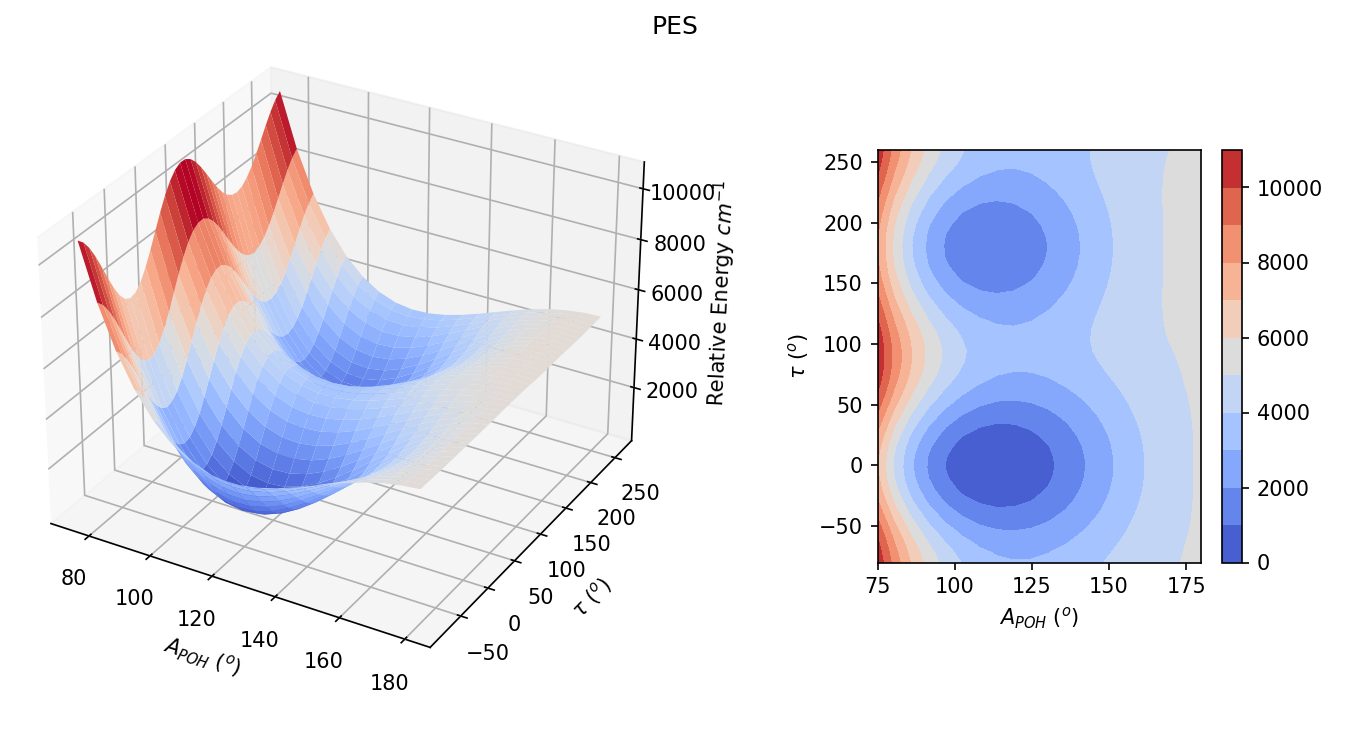

In [13]:
fig = plt.figure(figsize=(9, 5))
fig.suptitle('PES')
ax_3d = fig.add_axes([-0.1, 0.08, 0.7, 0.9], projection='3d')
#ax_3d = fig.add_subplot(1, 2, 1, projection='3d')
ax_3d.plot_surface(
    apoh_mesh, tau_mesh, pes_vals,
    cmap=cm.coolwarm,
    shade=True,           # adds lighting effect
)
#ax_3d.set_box_aspect([1,1,0.6]) 
ax_3d.set_xlabel(r'$A_{POH}$ ($^{o}$)')
ax_3d.set_ylabel(r'$\tau$ ($^{o}$)') 
ax_3d.set_zlabel(r'Relative Energy $cm^{-1}$');
ax_3d.axis('tight');

#ax_contour = fig.add_subplot(1, 2, 2, projection=None)
ax_contour = fig.add_axes([0.65, 0.25, 0.3, 0.55])  
contour = ax_contour.contourf(
    apoh_mesh, tau_mesh, pes_vals,
    levels=10,
    cmap=cm.coolwarm
)
ax_contour.set_xlabel(r'$A_{POH}$ ($^{o}$)')
ax_contour.set_ylabel(r'$\tau$ ($^{o}$)') 

plt.colorbar(contour, ax=ax_contour)
plt.show()

In [21]:
def pes_fitted_cis(input_geometry):
    input_geometry = np.append(input_geometry, 0)
    geometry = np.array([input_geometry])
    return pes(geometry)

def pes_fitted_trans(input_geometry):
    input_geometry = np.append(input_geometry, 180)
    geometry = np.array([input_geometry])
    return pes(geometry)

#guess = np.array([1.60346169, 1.46783211, 0.96779675, 110.73674459, 113.09775988])
guess = np.array([1.61099546, 1.46461729, 0.96380778, 110.46377558, 115.67092131])
cis_minima = minimize(pes_fitted_cis, guess, method='Nelder-Mead')
trans_minima = minimize(pes_fitted_trans, guess, method='Nelder-Mead')

print(cis_minima.x)
print()
print(trans_minima.x)

[  1.46785942   1.60353856   0.96778537 110.72541655 113.07605091]

[  1.4613902    1.61122616   0.96425298 108.4951826  111.97522231]
